<a href="https://colab.research.google.com/github/raannallq/GP/blob/main/Yet_another_copy_of_Untitled6555.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, random
np.random.seed(42)
random.seed(42)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
url = "https://raw.githubusercontent.com/latifahaljurayyan/insightApp/refs/heads/main/google_play_app_review.csv"
df = pd.read_csv(url)
print(df.shape)

(9862, 9)


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.3 MB/s eta 0:00:00


In [ ]:
df['tokens_str'] = df['tokens_str'].fillna("").astype(str)
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from gensim.models import Word2Vec
import numpy as np


X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    seed=42
)

def get_sentence_vector(tokens, model, vector_size):
  vectors = [model.wv[word] for word in tokens if word in model.wv]

  if len(vectors) ==0:
    return np.zeros(vector_size)

  return np.mean(vectors, axis=0)

X_train = np.array([get_sentence_vector(tokens, w2v_model, 100)for tokens in X_train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4453
Negative    2991
Neutral      445
Name: count, dtype: int64
After SMOTE: sentiment_label
Positive    4453
Negative    4453
Neutral     4453
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7835783071464775
Classification Report:
               precision    recall  f1-score   support

    Negative       0.75      0.80      0.77       748
     Neutral       0.10      0.08      0.09       111
    Positive       0.87      0.84      0.86      1114

    accuracy                           0.78      1973
   macro avg       0.57      0.57      0.57      1973
weighted avg       0.78      0.78      0.78      1973



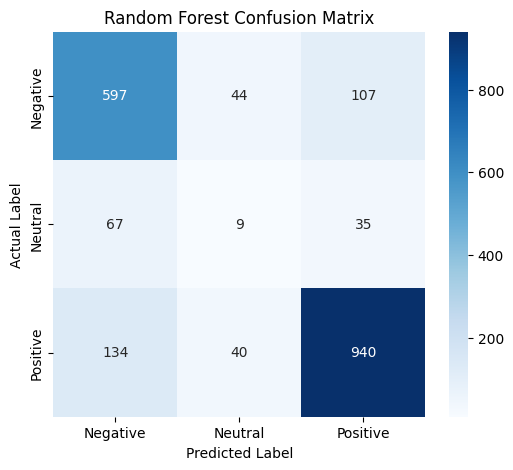

In [ ]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.685250886974151

Classification Report:

              precision    recall  f1-score   support

    Negative       0.69      0.63      0.66       748
     Neutral       0.11      0.23      0.14       111
    Positive       0.81      0.77      0.79      1114

    accuracy                           0.69      1973
   macro avg       0.54      0.54      0.53      1973
weighted avg       0.73      0.69      0.70      1973

Confusion Matrix:
 [[473 113 162]
 [ 52  25  34]
 [163  97 854]]


In [ ]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


SVM Accuracy: 0.7486061834769386

Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.75      0.76       748
     Neutral       0.13      0.32      0.18       111
    Positive       0.92      0.79      0.85      1114

    accuracy                           0.75      1973
   macro avg       0.60      0.62      0.60      1973
weighted avg       0.82      0.75      0.78      1973



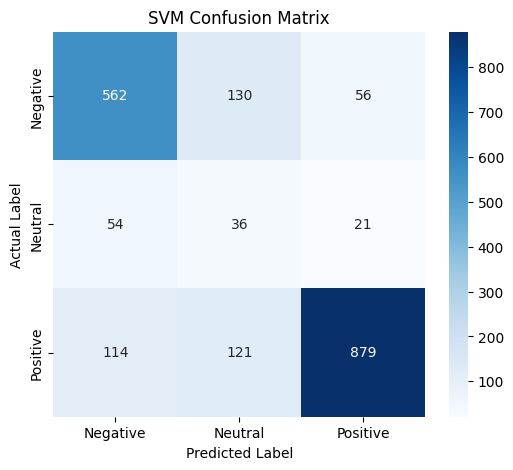

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6538266599087684

Classification Report:
               precision    recall  f1-score   support

    Negative       0.69      0.78      0.73       748
     Neutral       0.06      0.18      0.09       111
    Positive       0.87      0.62      0.72      1114

    accuracy                           0.65      1973
   macro avg       0.54      0.53      0.51      1973
weighted avg       0.76      0.65      0.69      1973

Confusion Matrix:
 [[583  85  80]
 [ 71  20  20]
 [187 240 687]]


In [ ]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:16:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8170299036999493

Classification Report:

              precision    recall  f1-score   support

    Negative       0.77      0.82      0.80       748
     Neutral       0.12      0.01      0.02       111
    Positive       0.85      0.89      0.87      1114

    accuracy                           0.82      1973
   macro avg       0.58      0.58      0.56      1973
weighted avg       0.78      0.82      0.80      1973

Confusion Matrix:

[[616   3 129]
 [ 69   1  41]
 [115   4 995]]
